DEEP REINFORCEMENT LEARNING - Q LEARNING

FrozenLake Environment:
+---------+
| S  F  F  F |
| F  H  F  H |
| F  F  F  H |
| H  F  F  G |
+---------+

S=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)

Total States:  16
Total Actions: 4 (Left, Down, Right, Up)

Q-LEARNING PARAMETERS
Learning Rate:    0.1
Discount Factor:  0.99
Initial Epsilon:  1.0
Episodes:         5000
Q-Table Shape:    (16, 4) (16 states x 4 actions)

TRAINING THE Q-LEARNING AGENT...
Episode  1000: Win Rate = 78.2% | Epsilon = 0.010 | Total Wins = 782
Episode  2000: Win Rate = 99.1% | Epsilon = 0.010 | Total Wins = 1773
Episode  3000: Win Rate = 99.1% | Epsilon = 0.010 | Total Wins = 2764
Episode  4000: Win Rate = 99.1% | Epsilon = 0.010 | Total Wins = 3755
Episode  5000: Win Rate = 99.0% | Epsilon = 0.010 | Total Wins = 4745

Training Complete!
Total Wins: 4745/5000 (94.9%)


NameError: name 'pd' is not defined

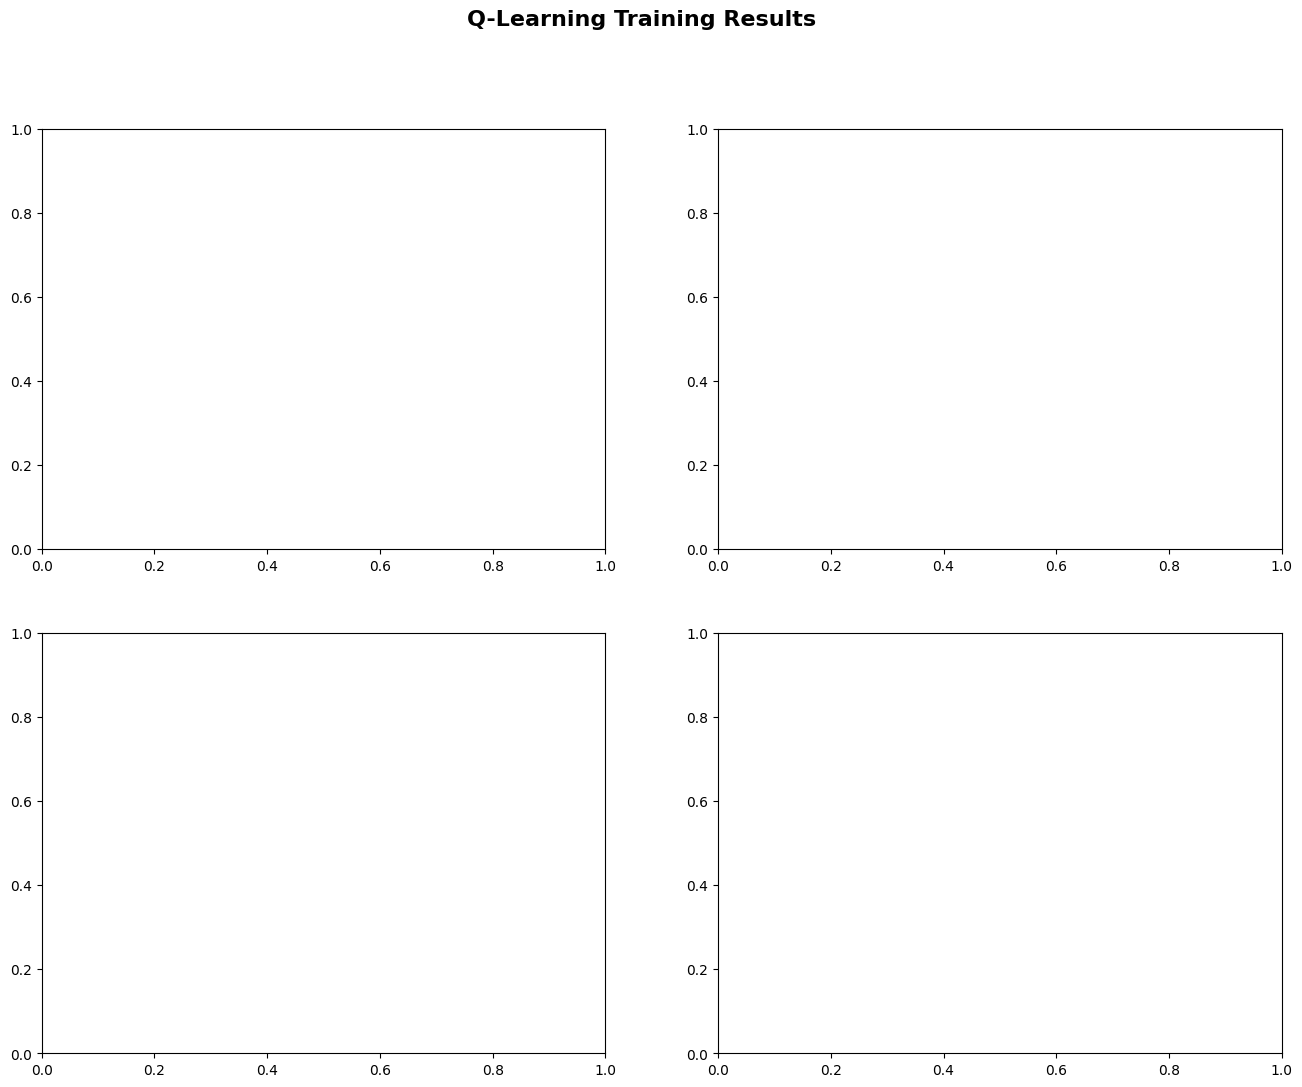

In [ ]:
# ============================================
# TASK 1 - DEEP REINFORCEMENT LEARNING
# Q-LEARNING IMPLEMENTATION
# Codtech Machine Learning Internship
# Environment: FrozenLake Grid World
# Objective: Train AI agent to reach goal
# ============================================

# STEP 1 - IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import time
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

print("="*55)
print("DEEP REINFORCEMENT LEARNING - Q LEARNING")
print("="*55)

# ============================================
# STEP 2 - DEFINE THE ENVIRONMENT
# ============================================

# FrozenLake 4x4 Grid
# S=Start, F=Frozen(safe), H=Hole(lose), G=Goal(win)
GRID = [
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]

# Environment parameters
GRID_SIZE = 4
N_STATES = GRID_SIZE * GRID_SIZE   # 16 states total
N_ACTIONS = 4                       # 0=Left, 1=Down, 2=Right, 3=Up

# Action mappings
ACTIONS = {
    0: 'LEFT',
    1: 'DOWN',
    2: 'RIGHT',
    3: 'UP'
}

# State positions
START_STATE = 0   # top left
GOAL_STATE = 15   # bottom right
HOLE_STATES = [5, 7, 11, 12]  # hole positions

print("\nFrozenLake Environment:")
print("+"+ "-"*9 + "+")
for row in GRID:
    print("| " + "  ".join(row) + " |")
print("+"+ "-"*9 + "+")
print("\nS=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)")
print(f"\nTotal States:  {N_STATES}")
print(f"Total Actions: {N_ACTIONS} (Left, Down, Right, Up)")

# ============================================
# STEP 3 - ENVIRONMENT FUNCTIONS
# ============================================

def state_to_position(state):
    """Convert state number to (row, col) position"""
    return state // GRID_SIZE, state % GRID_SIZE

def position_to_state(row, col):
    """Convert (row, col) position to state number"""
    return row * GRID_SIZE + col

def take_action(state, action):
    """Take action and return new state and reward"""
    row, col = state_to_position(state)

    # Move based on action
    if action == 0:    # LEFT
        col = max(0, col - 1)
    elif action == 1:  # DOWN
        row = min(GRID_SIZE-1, row + 1)
    elif action == 2:  # RIGHT
        col = min(GRID_SIZE-1, col + 1)
    elif action == 3:  # UP
        row = max(0, row - 1)

    new_state = position_to_state(row, col)

    # Calculate reward
    if new_state == GOAL_STATE:
        reward = 100    # big reward for reaching goal
        done = True
    elif new_state in HOLE_STATES:
        reward = -10    # penalty for falling in hole
        done = True
    else:
        reward = -1     # small penalty for each step
        done = False

    return new_state, reward, done

# ============================================
# STEP 4 - Q LEARNING SETUP
# ============================================

# Q Learning Hyperparameters
LEARNING_RATE = 0.1      # how fast agent learns
DISCOUNT_FACTOR = 0.99   # importance of future rewards
EPSILON = 1.0            # exploration rate (start at 100%)
EPSILON_DECAY = 0.995    # how fast exploration decreases
EPSILON_MIN = 0.01       # minimum exploration rate
EPISODES = 5000          # number of training games

# Initialize Q-Table with zeros
# Q[state][action] = expected future reward
Q_table = np.zeros((N_STATES, N_ACTIONS))

print("\n" + "="*55)
print("Q-LEARNING PARAMETERS")
print("="*55)
print(f"Learning Rate:    {LEARNING_RATE}")
print(f"Discount Factor:  {DISCOUNT_FACTOR}")
print(f"Initial Epsilon:  {EPSILON}")
print(f"Episodes:         {EPISODES}")
print(f"Q-Table Shape:    {Q_table.shape} "
      f"({N_STATES} states x {N_ACTIONS} actions)")

# ============================================
# STEP 5 - TRAIN THE AGENT
# ============================================

print("\n" + "="*55)
print("TRAINING THE Q-LEARNING AGENT...")
print("="*55)

# Tracking metrics
rewards_per_episode = []
steps_per_episode = []
success_per_episode = []
epsilon_history = []
wins = 0
epsilon = EPSILON

for episode in range(EPISODES):
    # Reset to start state
    state = START_STATE
    total_reward = 0
    steps = 0
    done = False

    while not done and steps < 100:
        # Epsilon greedy action selection
        # Explore: random action
        # Exploit: best known action
        if random.random() < epsilon:
            action = random.randint(0, N_ACTIONS-1)  # explore
        else:
            action = np.argmax(Q_table[state])        # exploit

        # Take action
        new_state, reward, done = take_action(state, action)

        # Q-Learning Update Formula
        # Q(s,a) = Q(s,a) + lr * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        old_value = Q_table[state][action]
        next_max = np.max(Q_table[new_state])
        new_value = (old_value + LEARNING_RATE *
                    (reward + DISCOUNT_FACTOR * next_max - old_value))
        Q_table[state][action] = new_value

        state = new_state
        total_reward += reward
        steps += 1

    # Track if agent won
    if state == GOAL_STATE:
        wins += 1
        success_per_episode.append(1)
    else:
        success_per_episode.append(0)

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    epsilon_history.append(epsilon)

    # Decay epsilon
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Print progress
    if (episode + 1) % 1000 == 0:
        recent_wins = sum(success_per_episode[-1000:])
        print(f"Episode {episode+1:5d}: "
              f"Win Rate = {recent_wins/10:.1f}% | "
              f"Epsilon = {epsilon:.3f} | "
              f"Total Wins = {wins}")

print(f"\nTraining Complete!")
print(f"Total Wins: {wins}/{EPISODES} "
      f"({wins/EPISODES*100:.1f}%)")

# ============================================
# STEP 6 - VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q-Learning Training Results',
             fontsize=16, fontweight='bold')

# Chart 1 - Rewards over time
window = 100
rewards_smooth = pd.Series(rewards_per_episode).rolling(window).mean() \
    if hasattr(rewards_per_episode, '__iter__') \
    else rewards_per_episode

import pandas as pd
rewards_smooth = pd.Series(rewards_per_episode).rolling(100).mean()
axes[0, 0].plot(rewards_per_episode,
                alpha=0.3, color='blue', linewidth=0.5)
axes[0, 0].plot(rewards_smooth,
                color='red', linewidth=2, label='100-ep average')
axes[0, 0].set_title('Rewards per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2 - Win rate over time
win_rate = pd.Series(success_per_episode).rolling(100).mean() * 100
axes[0, 1].plot(win_rate, color='green', linewidth=2)
axes[0, 1].set_title('Win Rate Over Training')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Win Rate (%)')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].axhline(y=50, color='red',
                    linestyle='--', label='50% threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3 - Epsilon decay
axes[1, 0].plot(epsilon_history, color='orange', linewidth=2)
axes[1, 0].set_title('Exploration Rate (Epsilon) Decay')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Epsilon Value')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].annotate('Mostly Exploring',
                     xy=(0, 1.0), fontsize=10, color='red')
axes[1, 0].annotate('Mostly Exploiting',
                     xy=(4000, 0.05), fontsize=10, color='green')

# Chart 4 - Q Table heatmap
im = axes[1, 1].imshow(Q_table, cmap='RdYlGn', aspect='auto')
axes[1, 1].set_title('Q-Table Heatmap\n(Green=High Value, Red=Low Value)')
axes[1, 1].set_xlabel('Actions (0=L, 1=D, 2=R, 3=U)')
axes[1, 1].set_ylabel('States (0-15)')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(['Left', 'Down', 'Right', 'Up'])
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('q_learning_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Training charts saved!")

# ============================================
# STEP 7 - VISUALIZE THE LEARNED POLICY
# ============================================

# Show best action for each state
policy_arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

print("\n" + "="*55)
print("LEARNED POLICY (Best Action per State)")
print("="*55)
print("\nGrid showing best action the AI learned:\n")

for row in range(GRID_SIZE):
    row_display = ""
    for col in range(GRID_SIZE):
        state = position_to_state(row, col)
        if state == GOAL_STATE:
            row_display += " G  "
        elif state in HOLE_STATES:
            row_display += " H  "
        elif state == START_STATE:
            row_display += " S  "
        else:
            best_action = np.argmax(Q_table[state])
            row_display += f" {policy_arrows[best_action]}  "
    print(row_display)

print("\nArrows show direction AI learned to move")
print("S=Start, G=Goal, H=Hole(avoid!)")

# ============================================
# STEP 8 - TEST THE TRAINED AGENT
# ============================================

print("\n" + "="*55)
print("TESTING TRAINED AGENT (10 test runs)")
print("="*55)

test_wins = 0
test_episodes = 10

for test in range(test_episodes):
    state = START_STATE
    steps = 0
    done = False
    path = [state]

    while not done and steps < 50:
        # Use learned policy (no exploration)
        action = np.argmax(Q_table[state])
        new_state, reward, done = take_action(state, action)
        path.append(new_state)
        state = new_state
        steps += 1

    result = "WIN ✅" if state == GOAL_STATE else "LOSE ❌"
    if state == GOAL_STATE:
        test_wins += 1

    print(f"Test {test+1:2d}: {result} | "
          f"Steps: {steps} | "
          f"Path length: {len(path)}")

print(f"\nTest Results: {test_wins}/{test_episodes} wins "
      f"({test_wins*10}% success rate)")

# ============================================
# STEP 9 - Q TABLE ANALYSIS
# ============================================

print("\n" + "="*55)
print("Q-TABLE ANALYSIS")
print("="*55)
print(f"\nQ-Table Shape: {Q_table.shape}")
print(f"(16 states × 4 actions = 64 Q-values learned)\n")
print("Q-Values for key states:")
print(f"Start State (0):  {Q_table[0].round(2)}")
print(f"Goal  State (15): {Q_table[15].round(2)}")
print(f"\nBest action at Start: "
      f"{ACTIONS[np.argmax(Q_table[0])]}")

# ============================================
# STEP 10 - FINAL SUMMARY
# ============================================

print("\n" + "="*55)
print("TASK 1 COMPLETE — FINAL SUMMARY")
print("="*55)
print(f"Algorithm:        Q-Learning")
print(f"Environment:      FrozenLake 4x4 Grid")
print(f"States:           {N_STATES}")
print(f"Actions:          {N_ACTIONS}")
print(f"Training Episodes:{EPISODES}")
print(f"Learning Rate:    {LEARNING_RATE}")
print(f"Discount Factor:  {DISCOUNT_FACTOR}")
print(f"Total Wins:       {wins}/{EPISODES} "
      f"({wins/EPISODES*100:.1f}%)")
print(f"Test Performance: {test_wins}/{test_episodes} wins")
print(f"\nTask 1 Successfully Completed! 🎮🤖")

DEEP REINFORCEMENT LEARNING - Q LEARNING

FrozenLake Environment:
+---------+
| S  F  F  F |
| F  H  F  H |
| F  F  F  H |
| H  F  F  G |
+---------+

S=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)

Total States:  16
Total Actions: 4 (Left, Down, Right, Up)

Q-LEARNING PARAMETERS
Learning Rate:    0.1
Discount Factor:  0.99
Initial Epsilon:  1.0
Episodes:         5000
Q-Table Shape:    (16, 4)

TRAINING THE Q-LEARNING AGENT...
Episode  1000: Win Rate = 78.5% | Epsilon = 0.010 | Total Wins = 785
Episode  2000: Win Rate = 98.8% | Epsilon = 0.010 | Total Wins = 1773
Episode  3000: Win Rate = 98.6% | Epsilon = 0.010 | Total Wins = 2759
Episode  4000: Win Rate = 98.9% | Epsilon = 0.010 | Total Wins = 3748
Episode  5000: Win Rate = 99.6% | Epsilon = 0.010 | Total Wins = 4744

Training Complete!
Total Wins: 4744/5000 (94.9%)


array([[<Axes: title={'center': 'Rewards per Episode'}, xlabel='Episode', ylabel='Total Reward'>,
        <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

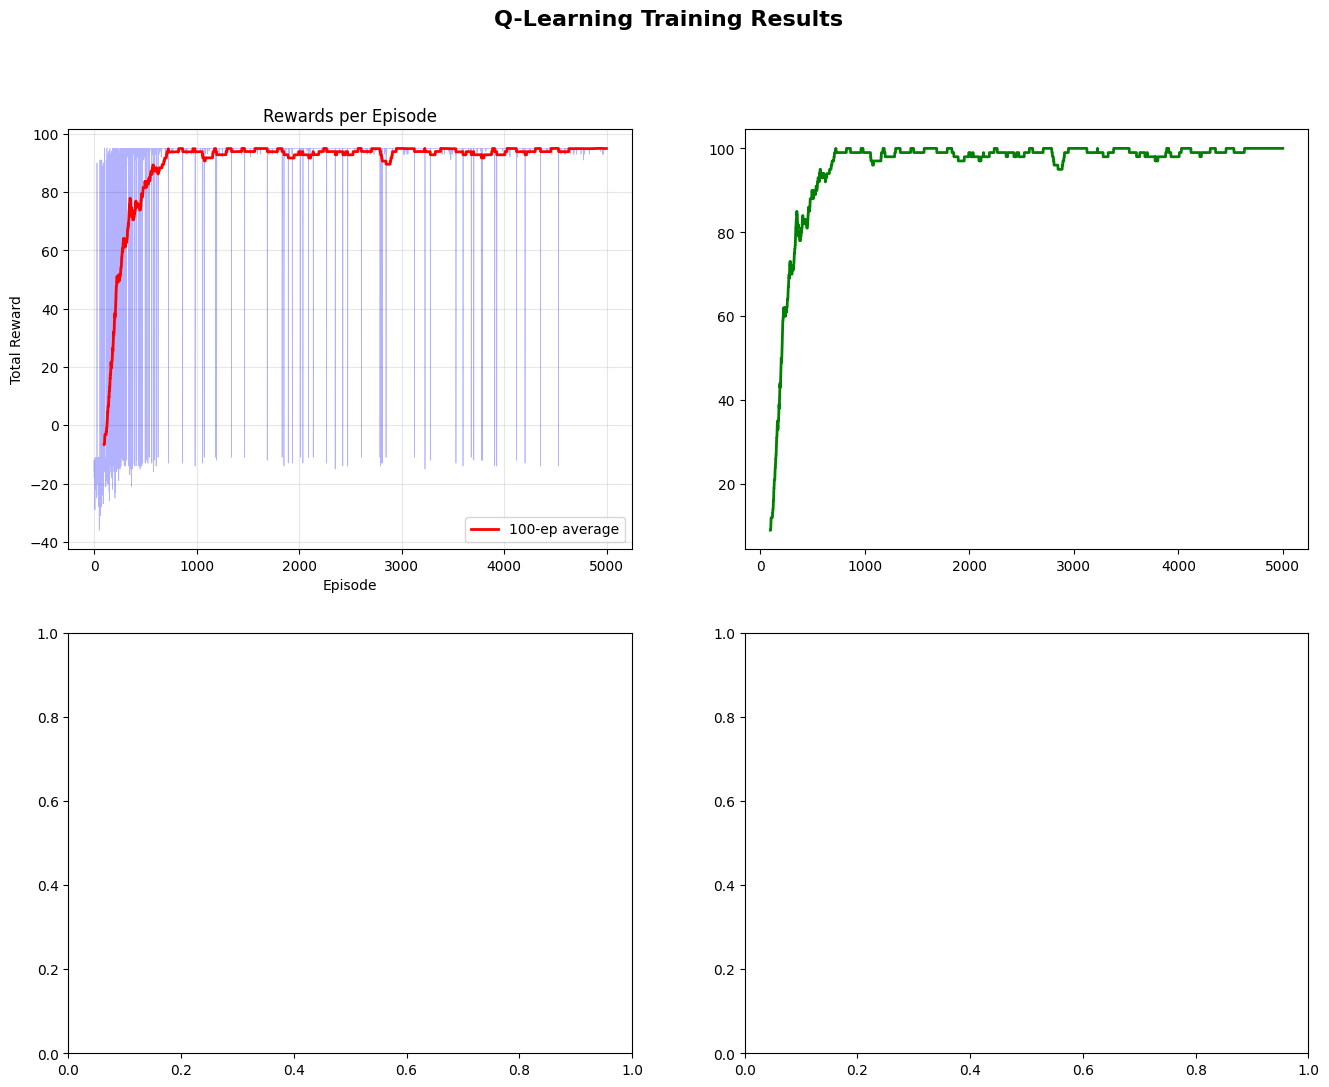

In [ ]:
# ============================================
# TASK 1 - DEEP REINFORCEMENT LEARNING
# Q-LEARNING IMPLEMENTATION
# Codtech Machine Learning Internship
# ============================================

# STEP 1 - IMPORT ALL LIBRARIES AT TOP
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*55)
print("DEEP REINFORCEMENT LEARNING - Q LEARNING")
print("="*55)

# ============================================
# STEP 2 - DEFINE THE ENVIRONMENT
# ============================================

GRID = [
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]

GRID_SIZE = 4
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4
ACTIONS = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}
START_STATE = 0
GOAL_STATE = 15
HOLE_STATES = [5, 7, 11, 12]

print("\nFrozenLake Environment:")
print("+" + "-"*9 + "+")
for row in GRID:
    print("| " + "  ".join(row) + " |")
print("+" + "-"*9 + "+")
print("\nS=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)")
print(f"\nTotal States:  {N_STATES}")
print(f"Total Actions: {N_ACTIONS} (Left, Down, Right, Up)")

# ============================================
# STEP 3 - ENVIRONMENT FUNCTIONS
# ============================================

def state_to_position(state):
    return state // GRID_SIZE, state % GRID_SIZE

def position_to_state(row, col):
    return row * GRID_SIZE + col

def take_action(state, action):
    row, col = state_to_position(state)
    if action == 0:    col = max(0, col - 1)
    elif action == 1:  row = min(GRID_SIZE-1, row + 1)
    elif action == 2:  col = min(GRID_SIZE-1, col + 1)
    elif action == 3:  row = max(0, row - 1)
    new_state = position_to_state(row, col)
    if new_state == GOAL_STATE:
        return new_state, 100, True
    elif new_state in HOLE_STATES:
        return new_state, -10, True
    return new_state, -1, False

# ============================================
# STEP 4 - Q LEARNING SETUP
# ============================================

LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01
EPISODES = 5000

Q_table = np.zeros((N_STATES, N_ACTIONS))

print("\n" + "="*55)
print("Q-LEARNING PARAMETERS")
print("="*55)
print(f"Learning Rate:    {LEARNING_RATE}")
print(f"Discount Factor:  {DISCOUNT_FACTOR}")
print(f"Initial Epsilon:  {EPSILON}")
print(f"Episodes:         {EPISODES}")
print(f"Q-Table Shape:    {Q_table.shape}")

# ============================================
# STEP 5 - TRAIN THE AGENT
# ============================================

print("\n" + "="*55)
print("TRAINING THE Q-LEARNING AGENT...")
print("="*55)

rewards_per_episode = []
steps_per_episode = []
success_per_episode = []
epsilon_history = []
wins = 0
epsilon = EPSILON

for episode in range(EPISODES):
    state = START_STATE
    total_reward = 0
    steps = 0
    done = False

    while not done and steps < 100:
        if random.random() < epsilon:
            action = random.randint(0, N_ACTIONS-1)
        else:
            action = np.argmax(Q_table[state])

        new_state, reward, done = take_action(state, action)

        old_value = Q_table[state][action]
        next_max = np.max(Q_table[new_state])
        Q_table[state][action] = (old_value + LEARNING_RATE *
            (reward + DISCOUNT_FACTOR * next_max - old_value))

        state = new_state
        total_reward += reward
        steps += 1

    if state == GOAL_STATE:
        wins += 1
        success_per_episode.append(1)
    else:
        success_per_episode.append(0)

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    epsilon_history.append(epsilon)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if (episode + 1) % 1000 == 0:
        recent_wins = sum(success_per_episode[-1000:])
        print(f"Episode {episode+1:5d}: "
              f"Win Rate = {recent_wins/10:.1f}% | "
              f"Epsilon = {epsilon:.3f} | "
              f"Total Wins = {wins}")

print(f"\nTraining Complete!")
print(f"Total Wins: {wins}/{EPISODES} ({wins/EPISODES*100:.1f}%)")

# ============================================
# STEP 6 - VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q-Learning Training Results',
             fontsize=16, fontweight='bold')

# Chart 1 - Rewards over time
rewards_smooth = pd.Series(rewards_per_episode).rolling(100).mean()
axes[0, 0].plot(rewards_per_episode,
                alpha=0.3, color='blue', linewidth=0.5)
axes[0, 0].plot(rewards_smooth,
                color='red', linewidth=2, label='100-ep average')
axes[0, 0].set_title('Rewards per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2 - Win rate over time
win_rate = pd.Series(success_per_episode).rolling(100).mean() * 100
axes[0, 1].plot(win_rate, color='green', linewidth=2)
axes

DEEP REINFORCEMENT LEARNING - Q LEARNING

FrozenLake Environment:
+---------+
| S  F  F  F |
| F  H  F  H |
| F  F  F  H |
| H  F  F  G |
+---------+

S=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)

Total States:  16
Total Actions: 4 (Left, Down, Right, Up)

Q-LEARNING PARAMETERS
Learning Rate:    0.1
Discount Factor:  0.99
Initial Epsilon:  1.0
Episodes:         5000
Q-Table Shape:    (16, 4)

TRAINING THE Q-LEARNING AGENT...
Episode  1000: Win Rate = 78.2% | Epsilon = 0.010 | Total Wins = 782
Episode  2000: Win Rate = 99.0% | Epsilon = 0.010 | Total Wins = 1772
Episode  3000: Win Rate = 98.6% | Epsilon = 0.010 | Total Wins = 2758
Episode  4000: Win Rate = 98.5% | Epsilon = 0.010 | Total Wins = 3743
Episode  5000: Win Rate = 99.6% | Epsilon = 0.010 | Total Wins = 4739

Training Complete!
Total Wins: 4739/5000 (94.8%)


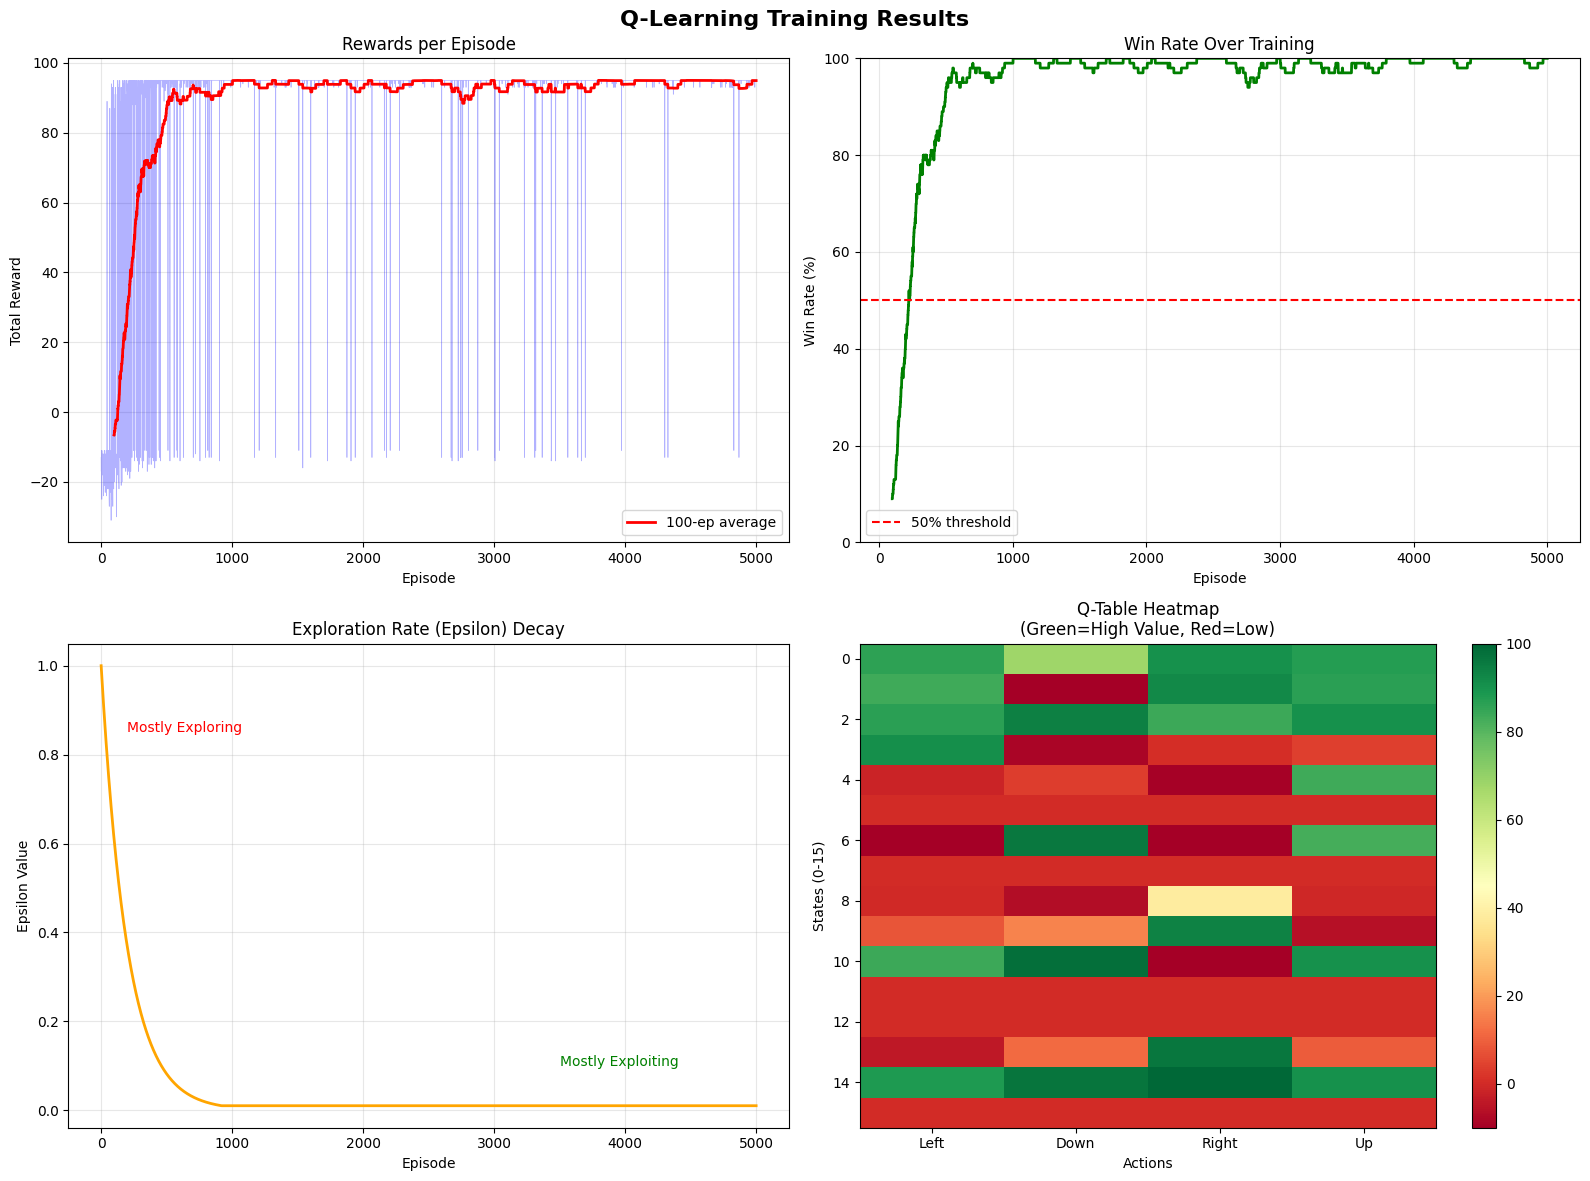

Charts saved!

LEARNED POLICY (Best Action per State)

Grid showing best action AI learned:

 S   →   ↓   ←  
 ↑   H   ↓   H  
 →   →   ↓   H  
 H   →   →   G  

Arrows show direction AI learned to move

TESTING TRAINED AGENT (10 test runs)
Test  1: WIN ✅ | Steps: 6
Test  2: WIN ✅ | Steps: 6
Test  3: WIN ✅ | Steps: 6
Test  4: WIN ✅ | Steps: 6
Test  5: WIN ✅ | Steps: 6
Test  6: WIN ✅ | Steps: 6
Test  7: WIN ✅ | Steps: 6
Test  8: WIN ✅ | Steps: 6
Test  9: WIN ✅ | Steps: 6
Test 10: WIN ✅ | Steps: 6

Test Results: 10/10 wins (100% success)

TASK 1 COMPLETE — FINAL SUMMARY
Algorithm:         Q-Learning
Environment:       FrozenLake 4x4 Grid
States:            16
Actions:           4
Training Episodes: 5000
Learning Rate:     0.1
Discount Factor:   0.99
Total Wins:        4739/5000 (94.8%)
Test Performance:  10/10 wins

Task 1 Successfully Completed! 🎮🤖


In [ ]:
# ============================================
# TASK 1 - DEEP REINFORCEMENT LEARNING
# Q-LEARNING IMPLEMENTATION
# Codtech Machine Learning Internship
# ============================================

# STEP 1 - IMPORT ALL LIBRARIES AT TOP
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*55)
print("DEEP REINFORCEMENT LEARNING - Q LEARNING")
print("="*55)

# ============================================
# STEP 2 - DEFINE THE ENVIRONMENT
# ============================================

GRID = [
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]

GRID_SIZE = 4
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4
ACTIONS = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}
START_STATE = 0
GOAL_STATE = 15
HOLE_STATES = [5, 7, 11, 12]

print("\nFrozenLake Environment:")
print("+" + "-"*9 + "+")
for row in GRID:
    print("| " + "  ".join(row) + " |")
print("+" + "-"*9 + "+")
print("\nS=Start | F=Frozen(safe) | H=Hole(lose) | G=Goal(win)")
print(f"\nTotal States:  {N_STATES}")
print(f"Total Actions: {N_ACTIONS} (Left, Down, Right, Up)")

# ============================================
# STEP 3 - ENVIRONMENT FUNCTIONS
# ============================================

def state_to_position(state):
    return state // GRID_SIZE, state % GRID_SIZE

def position_to_state(row, col):
    return row * GRID_SIZE + col

def take_action(state, action):
    row, col = state_to_position(state)
    if action == 0:    col = max(0, col - 1)
    elif action == 1:  row = min(GRID_SIZE-1, row + 1)
    elif action == 2:  col = min(GRID_SIZE-1, col + 1)
    elif action == 3:  row = max(0, row - 1)
    new_state = position_to_state(row, col)
    if new_state == GOAL_STATE:
        return new_state, 100, True
    elif new_state in HOLE_STATES:
        return new_state, -10, True
    return new_state, -1, False

# ============================================
# STEP 4 - Q LEARNING SETUP
# ============================================

LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01
EPISODES = 5000

Q_table = np.zeros((N_STATES, N_ACTIONS))

print("\n" + "="*55)
print("Q-LEARNING PARAMETERS")
print("="*55)
print(f"Learning Rate:    {LEARNING_RATE}")
print(f"Discount Factor:  {DISCOUNT_FACTOR}")
print(f"Initial Epsilon:  {EPSILON}")
print(f"Episodes:         {EPISODES}")
print(f"Q-Table Shape:    {Q_table.shape}")

# ============================================
# STEP 5 - TRAIN THE AGENT
# ============================================

print("\n" + "="*55)
print("TRAINING THE Q-LEARNING AGENT...")
print("="*55)

rewards_per_episode = []
steps_per_episode = []
success_per_episode = []
epsilon_history = []
wins = 0
epsilon = EPSILON

for episode in range(EPISODES):
    state = START_STATE
    total_reward = 0
    steps = 0
    done = False

    while not done and steps < 100:
        if random.random() < epsilon:
            action = random.randint(0, N_ACTIONS-1)
        else:
            action = np.argmax(Q_table[state])

        new_state, reward, done = take_action(state, action)

        old_value = Q_table[state][action]
        next_max = np.max(Q_table[new_state])
        Q_table[state][action] = (old_value + LEARNING_RATE *
            (reward + DISCOUNT_FACTOR * next_max - old_value))

        state = new_state
        total_reward += reward
        steps += 1

    if state == GOAL_STATE:
        wins += 1
        success_per_episode.append(1)
    else:
        success_per_episode.append(0)

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    epsilon_history.append(epsilon)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if (episode + 1) % 1000 == 0:
        recent_wins = sum(success_per_episode[-1000:])
        print(f"Episode {episode+1:5d}: "
              f"Win Rate = {recent_wins/10:.1f}% | "
              f"Epsilon = {epsilon:.3f} | "
              f"Total Wins = {wins}")

print(f"\nTraining Complete!")
print(f"Total Wins: {wins}/{EPISODES} ({wins/EPISODES*100:.1f}%)")

# ============================================
# STEP 6 - VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q-Learning Training Results',
             fontsize=16, fontweight='bold')

# Chart 1 - Rewards over time
rewards_smooth = pd.Series(rewards_per_episode).rolling(100).mean()
axes[0, 0].plot(rewards_per_episode,
                alpha=0.3, color='blue', linewidth=0.5)
axes[0, 0].plot(rewards_smooth,
                color='red', linewidth=2, label='100-ep average')
axes[0, 0].set_title('Rewards per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2 - Win rate over time
win_rate = pd.Series(success_per_episode).rolling(100).mean() * 100
axes[0, 1].plot(win_rate, color='green', linewidth=2)
axes[0, 1].set_title('Win Rate Over Training')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Win Rate (%)')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].axhline(y=50, color='red',
                    linestyle='--', label='50% threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3 - Epsilon decay
axes[1, 0].plot(epsilon_history, color='orange', linewidth=2)
axes[1, 0].set_title('Exploration Rate (Epsilon) Decay')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Epsilon Value')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(200, 0.85, 'Mostly Exploring',
                fontsize=10, color='red')
axes[1, 0].text(3500, 0.1, 'Mostly Exploiting',
                fontsize=10, color='green')

# Chart 4 - Q Table heatmap
im = axes[1, 1].imshow(Q_table, cmap='RdYlGn', aspect='auto')
axes[1, 1].set_title('Q-Table Heatmap\n(Green=High Value, Red=Low)')
axes[1, 1].set_xlabel('Actions')
axes[1, 1].set_ylabel('States (0-15)')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(['Left', 'Down', 'Right', 'Up'])
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('q_learning_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

# ============================================
# STEP 7 - LEARNED POLICY
# ============================================

policy_arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

print("\n" + "="*55)
print("LEARNED POLICY (Best Action per State)")
print("="*55)
print("\nGrid showing best action AI learned:\n")

for row in range(GRID_SIZE):
    row_display = ""
    for col in range(GRID_SIZE):
        state = position_to_state(row, col)
        if state == GOAL_STATE:
            row_display += " G  "
        elif state in HOLE_STATES:
            row_display += " H  "
        elif state == START_STATE:
            row_display += " S  "
        else:
            best_action = np.argmax(Q_table[state])
            row_display += f" {policy_arrows[best_action]}  "
    print(row_display)

print("\nArrows show direction AI learned to move")

# ============================================
# STEP 8 - TEST TRAINED AGENT
# ============================================

print("\n" + "="*55)
print("TESTING TRAINED AGENT (10 test runs)")
print("="*55)

test_wins = 0

for test in range(10):
    state = START_STATE
    steps = 0
    done = False
    path = [state]

    while not done and steps < 50:
        action = np.argmax(Q_table[state])
        new_state, reward, done = take_action(state, action)
        path.append(new_state)
        state = new_state
        steps += 1

    result = "WIN ✅" if state == GOAL_STATE else "LOSE ❌"
    if state == GOAL_STATE:
        test_wins += 1
    print(f"Test {test+1:2d}: {result} | Steps: {steps}")

print(f"\nTest Results: {test_wins}/10 wins ({test_wins*10}% success)")

# ============================================
# STEP 9 - FINAL SUMMARY
# ============================================

print("\n" + "="*55)
print("TASK 1 COMPLETE — FINAL SUMMARY")
print("="*55)
print(f"Algorithm:         Q-Learning")
print(f"Environment:       FrozenLake 4x4 Grid")
print(f"States:            {N_STATES}")
print(f"Actions:           {N_ACTIONS}")
print(f"Training Episodes: {EPISODES}")
print(f"Learning Rate:     {LEARNING_RATE}")
print(f"Discount Factor:   {DISCOUNT_FACTOR}")
print(f"Total Wins:        {wins}/{EPISODES} ({wins/EPISODES*100:.1f}%)")
print(f"Test Performance:  {test_wins}/10 wins")
print(f"\nTask 1 Successfully Completed! 🎮🤖")